##SECTION 1  - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

##SECTION 2 - load dataset

In [2]:
df=pd.read_csv("cleaned_cars.csv")

In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15409 entries, 0 to 15408
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15409 non-null  int64  
 1   car_name           15409 non-null  object 
 2   brand              15409 non-null  object 
 3   model              15409 non-null  object 
 4   vehicle_age        15409 non-null  int64  
 5   km_driven          15409 non-null  int64  
 6   seller_type        15409 non-null  object 
 7   fuel_type          15409 non-null  object 
 8   transmission_type  15409 non-null  object 
 9   mileage            15409 non-null  float64
 10  engine             15409 non-null  int64  
 11  max_power          15409 non-null  float64
 12  seats              15409 non-null  int64  
 13  selling_price      15409 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


##Section 3  - define features and target

In [4]:
X=df.drop(columns=["selling_price","car_name","model"])
y=df["selling_price"]

In [5]:
print("X shape:",X.shape)
print("Y shape:",y.shape)

X shape: (15409, 11)
Y shape: (15409,)


##SECTION 4 - train test split

In [6]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
print("Training date:",X_train.shape)
print("Testing date:",y_test.shape)

Training date: (12327, 11)
Testing date: (3082,)


##SECTION 5 - Identify columns

In [8]:
numerical_columns=[
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

In [9]:
categorial_columns=[
    "brand",
    "fuel_type",
    "transmission_type",
    "seller_type"
]

In [10]:
print("Numerical columns:")
print(numerical_columns)
print("Categorical columns:")
print(categorial_columns)

Numerical columns:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Categorical columns:
['brand', 'fuel_type', 'transmission_type', 'seller_type']


##SECTION  6  - Create  Numerical preprocessor

In [11]:
numerical_pipeline=Pipeline(
    steps=[
        ("Imputer",SimpleImputer(strategy="median"))
    ]
)

##SECTION 7 - Create Categorical preprocessor

In [12]:
categorical_pipeline=Pipeline(
    steps=[
        ("imputer",
         SimpleImputer(strategy="most_frequent")),
        ("onehotencoder",OneHotEncoder(handle_unknown="ignore"))
    ]
)



```
# This is formatted as code
```

##SECTION 8- Combine both processor

In [13]:
preprocesso = ColumnTransformer(
    transformers=[
        ("num",
         numerical_pipeline,
         numerical_columns
         ),
        ("cat",
         categorical_pipeline,
         categorial_columns)
    ]
)

##SECTION 9  - Create ML model

In [14]:
Model=RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


##SECTION 10 - Create the complete pipeline

In [15]:
pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocesso),
        ("model",Model)
    ]
)

##SECTION 11 -Train the model

In [16]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['vehicle_age', 'km_driven',
                                                   'mileage', 'engine',
                                                   'max_power', 'seats']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['brand', 'fuel_type',
                                                   'transmission_type',
                                                   'seller_type'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

##SECTION 12 - Make prediction

In [17]:
y_pred=pipeline.predict(X_test)

In [18]:
comparison =pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})
comparison.head(10)

,Actual,Predicted
14004,298000,4.105600e+05
14433,3100000,2.766205e+06
10389,375000,4.411100e+05
10962,320000,3.706935e+05
3105,435000,4.444000e+05
6504,450000,4.983533e+05
511,470000,4.724200e+05
13613,1085000,1.049260e+06
12729,700000,7.147900e+05
6885,200000,2.534600e+05


##SECTION 13 - Evaluate the model

In [19]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mae",mae)
print("mse",mse)
print("rmse",rmse)
print("r2",r2)

mae 95772.88218750028
mse 34714416446.41174
rmse 186318.0518533074
r2 0.9434567273315438


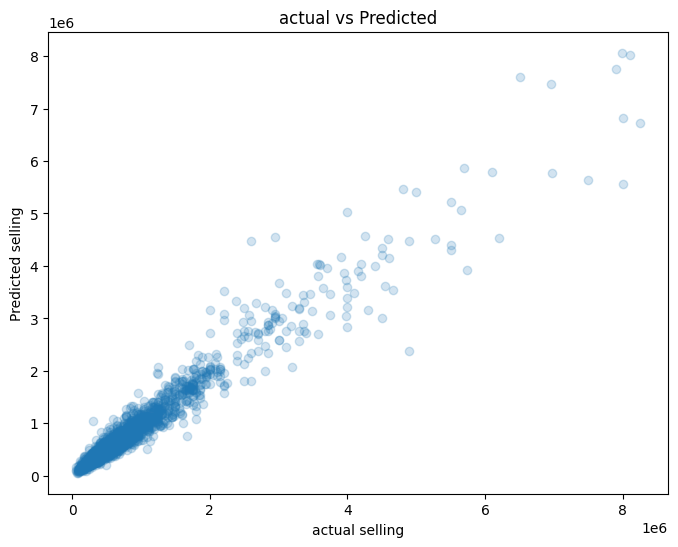

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,alpha=0.2)
plt.title("actual vs Predicted")
plt.ylabel("Predicted selling")
plt.xlabel("actual selling")
plt.show()


##SECTION 14 - Save the pipeline

In [22]:
import joblib
joblib.dump(
    pipeline,
    "car_price_prediction.pkl"
)

['car_price_prediction.pkl']

In [23]:
import os
print(os.path.exists("car_price_prediction.pkl"))

True
